In [1]:
import pandas as pd

df = pd.read_csv("../data/heart.csv")

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns)
print("\nFirst 5 Rows:")
print(df.head())

Dataset Shape: (1025, 14)

Columns:
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='str')

First 5 Rows:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  


In [2]:
print(df.columns)

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='str')


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import joblib

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [4]:
df = pd.read_csv("../data/heart.csv")

print(df.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  


In [5]:
print("Shape:", df.shape)

print("\nColumns")
print(df.columns)

print("\nInfo")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

Shape: (1025, 14)

Columns
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='str')

Info
<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None

Missing Values
age         0
sex

In [6]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 723


In [7]:
df = df.drop_duplicates()

print(df.shape)

(302, 14)


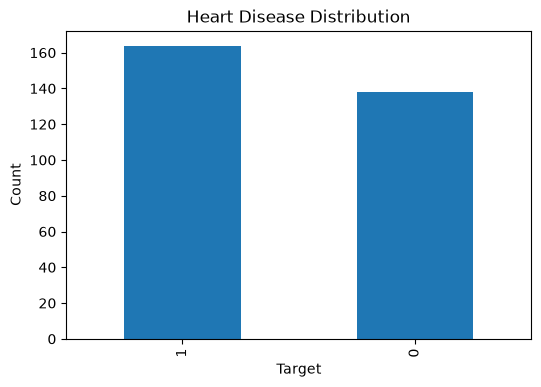

In [8]:
plt.figure(figsize=(6,4))

df["target"].value_counts().plot(kind="bar")

plt.title("Heart Disease Distribution")

plt.xlabel("Target")

plt.ylabel("Count")

plt.show()

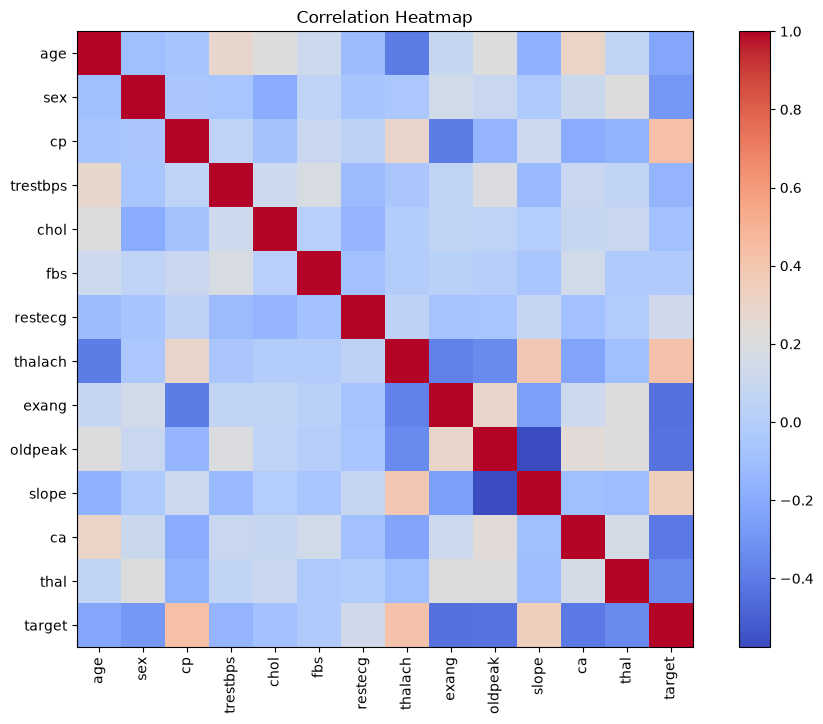

In [9]:
import matplotlib.pyplot as plt

correlation = df.corr()

plt.figure(figsize=(12,8))

plt.imshow(correlation, cmap="coolwarm", interpolation="nearest")

plt.colorbar()

plt.xticks(range(len(correlation.columns)),
           correlation.columns,
           rotation=90)

plt.yticks(range(len(correlation.columns)),
           correlation.columns)

plt.title("Correlation Heatmap")

plt.show()

In [10]:
X = df.drop("target", axis=1)

y = df["target"]

print(X.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  
0   2     3  
1   0     3  
2   0     3  
3   1     3  
4   3     2  


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Training Shape:", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape: (241, 13)
Testing Shape : (61, 13)


In [14]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=5000)

log_model.fit(X_train, y_train)

log_prediction = log_model.predict(X_test)

log_accuracy = accuracy_score(y_test, log_prediction)

print("Logistic Regression Accuracy:", log_accuracy)

Logistic Regression Accuracy: 0.7704918032786885


In [15]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_prediction = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_prediction)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.7377049180327869


In [16]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_prediction = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_prediction)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.8524590163934426


In [17]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

knn_prediction = knn_model.predict(X_test)

knn_accuracy = accuracy_score(y_test, knn_prediction)

print("KNN Accuracy:", knn_accuracy)

KNN Accuracy: 0.7377049180327869


In [18]:
results = {
    "Logistic Regression": log_accuracy,
    "Decision Tree": dt_accuracy,
    "Random Forest": rf_accuracy,
    "KNN": knn_accuracy
}

print("Model Accuracies:\n")

for model, accuracy in results.items():
    print(f"{model}: {accuracy:.4f}")

best_model_name = max(results, key=results.get)

print("\nBest Model:", best_model_name)
print("Best Accuracy:", results[best_model_name])

Model Accuracies:

Logistic Regression: 0.7705
Decision Tree: 0.7377
Random Forest: 0.8525
KNN: 0.7377

Best Model: Random Forest
Best Accuracy: 0.8524590163934426


     Feature  Importance
7    thalach    0.130246
2         cp    0.126030
9    oldpeak    0.118301
12      thal    0.113892
11        ca    0.096178
0        age    0.090891
3   trestbps    0.074502
4       chol    0.072694
10     slope    0.052614
8      exang    0.047001
1        sex    0.038327
6    restecg    0.027020
5        fbs    0.012303


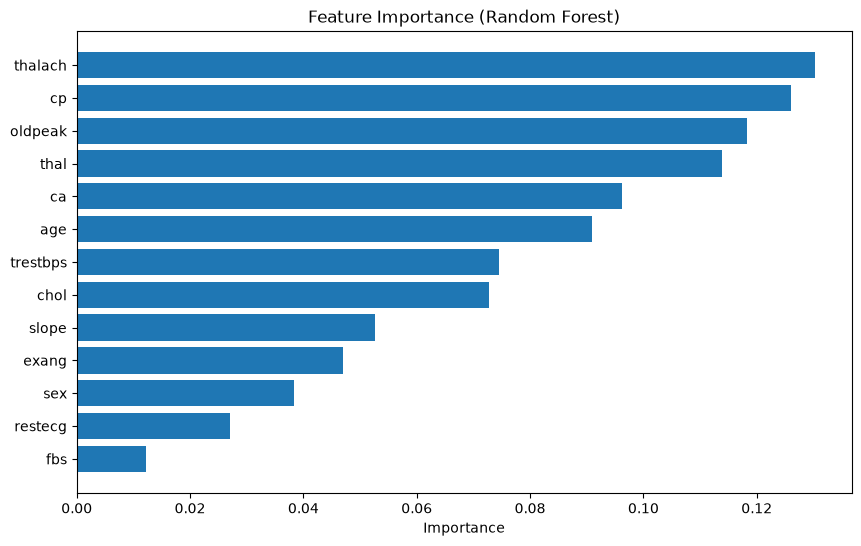

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.gca().invert_yaxis()

plt.show()

In [20]:
import joblib

joblib.dump(rf_model, "../heart_model.pkl")
joblib.dump(scaler, "../scaler.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [21]:
sample = X.iloc[[0]]

prediction = rf_model.predict(scaler.transform(sample))

if prediction[0] == 1:
    print("Heart Disease Detected")
else:
    print("No Heart Disease")

No Heart Disease


In [22]:
import os

print(os.getcwd())

c:\Users\Mohd Abdul Razzaq\Documents\heart-disease-prediction\notebook
